# Librosa
## This notebook outlines the installation and usage of Librosa library for Audio Processing

### Installation

In [1]:
#! pip install librosa

### Import the library

In [4]:
import librosa
import numpy as np

### Get the file path to an included audio example
- Use nutcracker

In [7]:
filename = librosa.example('nutcracker')

### Load the audio 
- Store the audio as a waveform `y`
- Store the sampling rate as `sr`

In [10]:
y, sr = librosa.load(filename)

### Set the hop length; at 22050 Hz, 512 samples ~ 23ms

In [12]:
hop_length = 512

### Separate harmonics and percussives into two waveforms

In [14]:
y_harmonic, y_percussive = librosa.effects.hpss(y)

In [15]:
y_percussive

array([ 1.3061011e-06,  3.4135076e-06, -4.7504541e-06, ...,
        4.0520295e-06,  7.1086388e-06,  3.9290103e-06], dtype=float32)

In [16]:
y_harmonic

array([ 9.6558631e-07,  1.9192105e-06, -2.4968735e-06, ...,
        7.1187228e-06, -5.8214418e-06,  1.4830551e-06], dtype=float32)

### Run the default beat tracker

In [18]:
tempo, beat_frames = librosa.beat.beat_track(y=y_percussive, sr=sr)

In [19]:
print(f'Estimated tempo: {tempo:.2f} beats per minute')

TypeError: unsupported format string passed to numpy.ndarray.__format__

### Convert the frame indices of beat events into timestamps

In [11]:
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

In [12]:
beat_times

array([  1.18421769,   1.71827664,   2.32199546,   2.87927438,
         3.45977324,   4.01705215,   4.59755102,   5.13160998,
         5.71210884,   6.26938776,   6.84988662,   7.40716553,
         7.9876644 ,   8.52172336,   9.12544218,   9.63628118,
        10.19356009,  10.70439909,  11.261678  ,  11.77251701,
        12.32979592,  12.86385488,  13.39791383,  13.93197279,
        14.46603175,  15.0000907 ,  15.53414966,  16.06820862,
        16.62548753,  17.15954649,  17.69360544,  18.2276644 ,
        18.7385034 ,  19.29578231,  19.85306122,  20.36390023,
        20.89795918,  21.43201814,  21.9660771 ,  22.50013605,
        23.05741497,  23.56825397,  24.10231293,  24.63637188,
        25.19365079,  25.7044898 ,  26.26176871,  26.81904762,
        27.35310658,  27.88716553,  28.44444444,  28.9785034 ,
        29.53578231,  30.09306122,  30.65034014,  31.20761905,
        31.76489796,  32.32217687,  32.83301587,  33.36707483,
        33.90113379,  34.43519274,  34.94603175,  35.45

### Compute MFCC features from the raw signal

In [13]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, hop_length=hop_length, n_mfcc=13)

### And the first-order differences (delta features)

In [14]:
mfcc_delta = librosa.feature.delta(mfcc)

### Stack and synchronize between beat events
- Use the mean value (default) instead of median

In [15]:
beat_mfcc_delta = librosa.util.sync(np.vstack([mfcc, mfcc_delta]),
                                    beat_frames)

### Compute chroma features from the harmonic signal

In [16]:
chromagram = librosa.feature.chroma_cqt(y=y_harmonic,
                                        sr=sr)

### Aggregate chroma features between beat events
- Use the median value of each feature between beat frames

In [17]:
beat_chroma = librosa.util.sync(chromagram,
                                beat_frames,
                                aggregate=np.median)

### Stack all beat-synchronous features together


In [18]:
beat_features = np.vstack([beat_chroma, beat_mfcc_delta])

Estimated Tempo: 184.57 BPM
Beat-synchronous feature shape: (38, 8)


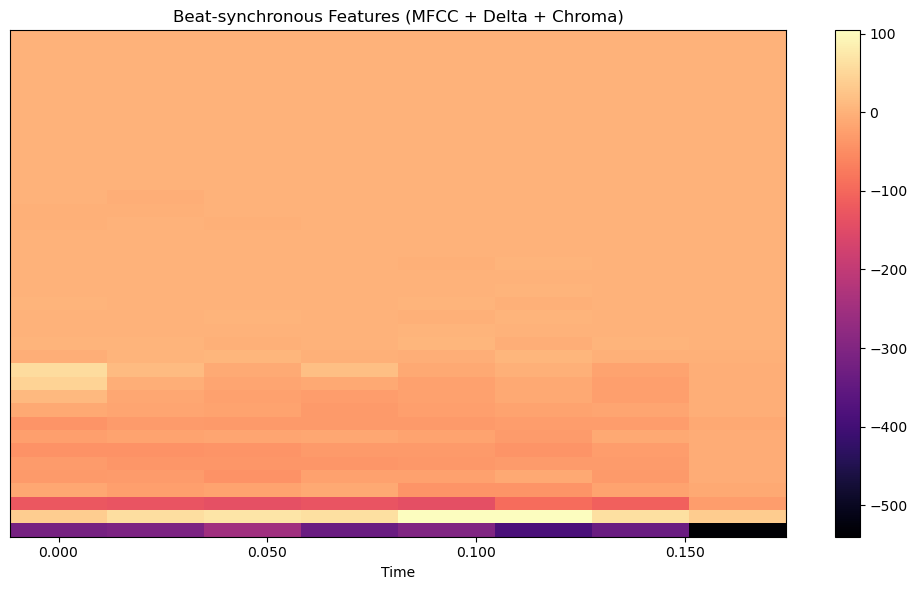

In [23]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入音訊檔案（這裡用 Librosa 的範例檔案）
y, sr = librosa.load(librosa.ex('trumpet'))  # 你也可以改成 'your_audio.wav'

# 2. 計算 MFCC 與導數
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc_delta = librosa.feature.delta(mfcc)

# 3. 節拍追蹤（beat tracking）
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
print(f'Estimated Tempo: {tempo[0]:.2f} BPM')

# 4. 節拍同步 MFCC 與其導數（預設 aggregate='mean'）
beat_mfcc_delta = librosa.util.sync(
    np.vstack([mfcc, mfcc_delta]),
    beat_frames
)

# 5. 提取和聲音訊 → chroma_cqt（色度特徵）
y_harmonic, y_percussive = librosa.effects.hpss(y)
chromagram = librosa.feature.chroma_cqt(y=y_harmonic, sr=sr)

# 6. 對齊節拍並用 median 聚合色度特徵
beat_chroma = librosa.util.sync(
    chromagram,
    beat_frames,
    aggregate=np.median
)

# 7. 堆疊所有節拍同步特徵
beat_features = np.vstack([beat_mfcc_delta, beat_chroma])
print("Beat-synchronous feature shape:", beat_features.shape)

# 8. 可選：視覺化
plt.figure(figsize=(10, 6))
librosa.display.specshow(beat_features, x_axis='time', sr=sr,
                         hop_length=512, cmap='magma')
plt.colorbar()
plt.title('Beat-synchronous Features (MFCC + Delta + Chroma)')
plt.tight_layout()
plt.show()


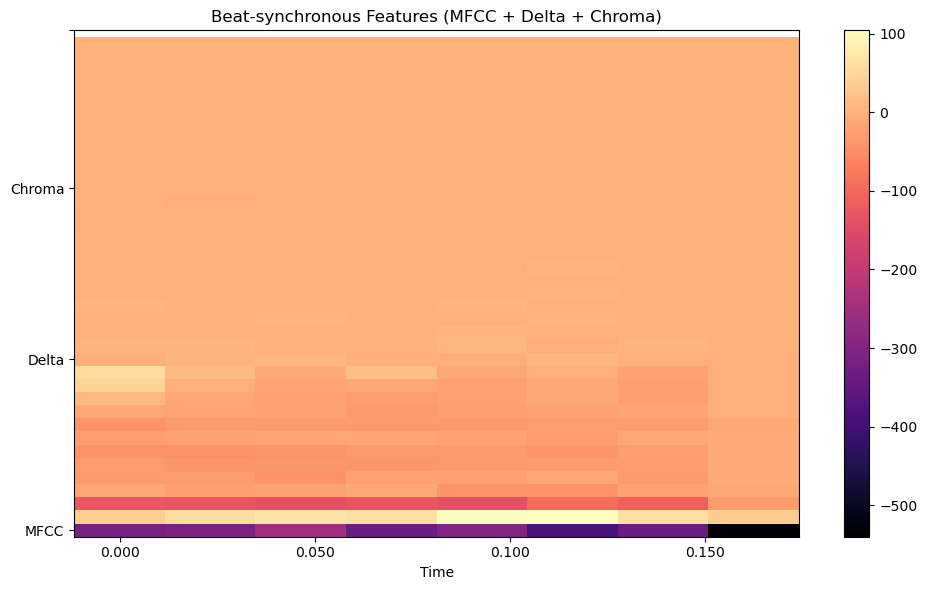

In [27]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 6))
librosa.display.specshow(
    beat_features,
    x_axis='time',
    sr=sr,
    hop_length=512,
    cmap='magma'
)

# 加上特徵區段標記
plt.yticks(
    ticks=[0, 13, 26, 38],
    labels=['MFCC', 'Delta', 'Chroma', '']
)

plt.colorbar()
plt.title('Beat-synchronous Features (MFCC + Delta + Chroma)')
plt.tight_layout()
plt.show()
